## Setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv("data/synthetic_student_week_data.csv")

# Boolean copies are used for filtering and plot labels.
df["treatment_b"] = df["treatment"].astype(bool)
df["post_b"] = df["post_period"].astype(bool)

# Integer 0/1 indicators keep the interaction term named treatment:post_period.
# Notebook 02 used bools (treatment[T.True]); the estimates are identical either way.
df["treatment"] = df["treatment_b"].astype(int)
df["post_period"] = df["post_b"].astype(int)

assert df["treatment"].isin([0, 1]).all()
assert df["post_period"].isin([0, 1]).all()

print("Rows:", len(df), "Students:", df["student_id"].nunique())
df.head()

Rows: 90761 Students: 8000


,student_id,grade_level,ses_band,baseline_score,baseline_engagement,treatment,week,post_period,weekly_active_days,assignments_completed,engagement_index,assessment_score,treatment_b,post_b
0,1,6,mid,72.786471,3.15067,0,1,0,3,2,2.5,69.946917,False,False
1,1,6,mid,72.786471,3.15067,0,3,0,2,2,2.0,71.182093,False,False
2,1,6,mid,72.786471,3.15067,0,4,0,4,5,4.5,70.695706,False,False
3,1,6,mid,72.786471,3.15067,0,5,0,4,1,2.5,72.494023,False,False
4,1,6,mid,72.786471,3.15067,0,6,0,3,2,2.5,72.593499,False,False


The panel has 90,761 student-week rows for 8,000 students. It is unbalanced: a fully observed panel would have 96,000 rows, so some student-weeks are missing by design of the synthetic data generation.

In [3]:
PRIMARY_OUTCOME = "weekly_active_days"
SECONDARY_OUTCOMES = ["assignments_completed", "engagement_index", "assessment_score"]

# Fail early if the CSV schema has drifted from notebook 01.
needed = [PRIMARY_OUTCOME] + SECONDARY_OUTCOMES + ["grade_level", "ses_band"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

print("Primary outcome:", PRIMARY_OUTCOME)
print("Secondary outcomes:", SECONDARY_OUTCOMES)

Primary outcome: weekly_active_days
Secondary outcomes: ['assignments_completed', 'engagement_index', 'assessment_score']


## Simple 2×2 difference-in-differences

In [4]:
means = (
    df.groupby(["treatment_b", "post_b"], as_index=False)[PRIMARY_OUTCOME]
      .mean()
      .rename(columns={"treatment_b": "treatment", "post_b": "post_period"})
)

display(means)

# DiD by hand: the treatment group's pre-to-post change minus the control group's.
mean_treat_post = means.query("treatment == True and post_period == True")[PRIMARY_OUTCOME].iloc[0]
mean_treat_pre  = means.query("treatment == True and post_period == False")[PRIMARY_OUTCOME].iloc[0]
mean_ctrl_post  = means.query("treatment == False and post_period == True")[PRIMARY_OUTCOME].iloc[0]
mean_ctrl_pre   = means.query("treatment == False and post_period == False")[PRIMARY_OUTCOME].iloc[0]

did_simple = (mean_treat_post - mean_treat_pre) - (mean_ctrl_post - mean_ctrl_pre)
print(f"Simple DiD estimate ({PRIMARY_OUTCOME}): {did_simple:.3f}")

,treatment,post_period,weekly_active_days
0,False,False,3.314776
1,False,True,3.046893
2,True,False,3.295507
3,True,True,3.400009


Simple DiD estimate (weekly_active_days): 0.372


Before the nudges, both groups were active about 3.3 days per week, as expected when students are randomly assigned. Afterward, the control group's average dropped by about a quarter of a day, while the nudged group's rose slightly. Comparing those two changes gives an estimated effect of about 0.37 extra active days per week.

## Weekly trends by group

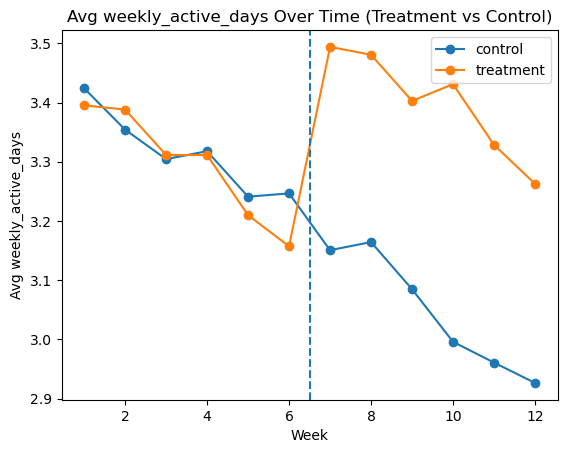

In [5]:
trend = (
    df.groupby(["week", "treatment_b"], as_index=False)[PRIMARY_OUTCOME]
      .mean()
      .sort_values(["week", "treatment_b"])
)

for key, g in trend.groupby("treatment_b"):
    label = "treatment" if key else "control"
    plt.plot(g["week"], g[PRIMARY_OUTCOME], marker="o", label=label)

# The line sits between week 6 (last pre-period week) and week 7 (first nudged week).
plt.axvline(x=6.5, linestyle="--")
plt.title(f"Avg {PRIMARY_OUTCOME} Over Time (Treatment vs Control)")
plt.xlabel("Week")
plt.ylabel(f"Avg {PRIMARY_OUTCOME}")
plt.legend()
plt.show()

Activity drops a little every week for both groups. Before the nudges, the two groups follow almost the same path. Once the nudges start in week 7, the nudged group's activity jumps by about a third of a day, and that gap holds through week 12. Both groups keep declining, though, so the nudges gave a lasting boost without reversing the overall slide. (The weekly decline is built into the synthetic data.)

## Regression DiD

In [6]:
# Grade and SES band are the randomization strata; adjusting for them tightens the estimate.
# HC3 robust SEs, not clustered by student; the student-level check below gives a nearly identical CI.
model = smf.ols(
    f"{PRIMARY_OUTCOME} ~ treatment * post_period + grade_level + ses_band",
    data=df
).fit(cov_type="HC3")

print(model.summary().tables[1])

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.8689      0.033    116.871      0.000       3.804       3.934
ses_band[T.low]          -0.9075      0.017    -52.677      0.000      -0.941      -0.874
ses_band[T.mid]          -0.4805      0.016    -30.013      0.000      -0.512      -0.449
treatment                -0.0179      0.018     -0.996      0.319      -0.053       0.017
post_period              -0.2672      0.018    -14.950      0.000      -0.302      -0.232
treatment:post_period     0.3724      0.025     14.730      0.000       0.323       0.422
grade_level              -0.0076      0.003     -2.384      0.017      -0.014      -0.001


The regression lands on the same answer as the simple comparison: nudged students were active about 0.37 more days per week, somewhere between 0.32 and 0.42. The two groups looked the same before the nudges, and accounting for grade and income level doesn't move the number, which is what random assignment should give you.

One technical note: this model treats each student's weeks as separate data points instead of grouping them by student. The student-level check later in the notebook counts each student only once and gets almost exactly the same range, so it doesn't seem to be a problem here.

## Effect size and percent lift

In [7]:
# Integer 0/1 indicators keep this term name fixed (see setup).
TERM = "treatment:post_period"

coef = model.params[TERM]
ci_low, ci_high = model.conf_int().loc[TERM]

# Percent lift is relative to the control group's pre-period mean,
# the group and period untouched by the nudges.
baseline = df.loc[(~df["post_b"]) & (~df["treatment_b"]), PRIMARY_OUTCOME].mean()
pct_lift = coef / baseline * 100

print(f"Effect ({TERM}): {coef:.3f} {PRIMARY_OUTCOME} units per week")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Baseline (control, pre): {baseline:.3f}")
print(f"Percent lift vs baseline: {pct_lift:.1f}%")

Effect (treatment:post_period): 0.372 weekly_active_days units per week
95% CI: [0.323, 0.422]
Baseline (control, pre): 3.315
Percent lift vs baseline: 11.2%


Students in the control group were active about 3.3 days a week before the nudges, so the extra 0.37 days works out to roughly an 11% boost.

## Secondary outcomes

In [8]:
# Same specification and baseline as the primary outcome, so effects are comparable.
rows = []
for outcome in SECONDARY_OUTCOMES:
    m = smf.ols(
        f"{outcome} ~ treatment * post_period + grade_level + ses_band",
        data=df
    ).fit(cov_type="HC3")

    coef = m.params[TERM]
    ci_low, ci_high = m.conf_int().loc[TERM]

    baseline = df.loc[(~df["post_b"]) & (~df["treatment_b"]), outcome].mean()
    # Guard against a zero baseline; percent lift is undefined there.
    pct = coef / baseline * 100 if baseline != 0 else np.nan

    rows.append({
        "outcome": outcome,
        "effect": coef,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "baseline_control_pre": baseline,
        "pct_lift_vs_baseline": pct
    })

results_secondary = pd.DataFrame(rows)
results_secondary.round(3)

,outcome,effect,ci_low,ci_high,baseline_control_pre,pct_lift_vs_baseline
0,assignments_completed,0.237,0.196,0.278,2.382,9.947
1,engagement_index,0.305,0.262,0.347,2.848,10.697
2,assessment_score,1.379,1.124,1.634,70.664,1.952


The nudges show up in the other measures too. Nudged students completed about 0.24 more assignments per week (about 10% more) and scored about 0.31 higher on the engagement index (about 11% more). Assessment scores went up about 1.4 points, which is close to the effect built into the synthetic data. On a baseline of roughly 71 points, though, that's only about a 2% bump, so the nudges seem to matter more for activity than for scores.

# Heterogeneity by baseline engagement

In [9]:
# 3.0 matches the low-engagement threshold used in data generation (notebook 01).
df["low_baseline_eng"] = (df["baseline_engagement"] < 3.0).astype(int)

het_model = smf.ols(
    f"{PRIMARY_OUTCOME} ~ treatment * post_period * low_baseline_eng + grade_level + ses_band",
    data=df
).fit(cov_type="HC3")

print(het_model.summary().tables[1])

# Not-low effect is treatment:post_period; low adds the three-way interaction.
# Indexing directly (not .get) so a renamed term raises an error instead of silently returning a default.
base_effect = het_model.params["treatment:post_period"]
extra_low = het_model.params["treatment:post_period:low_baseline_eng"]

print("\nImplied treatment effects:")
print(f"Not-low baseline engagement (>=3.0): {base_effect:.3f}")
print(f"Low baseline engagement (<3.0): {(base_effect + extra_low):.3f}")

                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  4.1474      0.032    129.832      0.000       4.085       4.210
ses_band[T.low]                           -0.5869      0.016    -35.857      0.000      -0.619      -0.555
ses_band[T.mid]                           -0.3273      0.015    -21.630      0.000      -0.357      -0.298
treatment                                 -0.0246      0.021     -1.168      0.243      -0.066       0.017
post_period                               -0.2647      0.021    -12.680      0.000      -0.306      -0.224
treatment:post_period                      0.2967      0.030      9.979      0.000       0.238       0.355
low_baseline_eng                          -1.6135      0.024    -67.900      0.000      -1.660      -1.567
treatment:low_baseline_eng           

The nudges helped students who started out less engaged the most. Students averaging under 3 active days a week gained about 0.54 extra days, compared with about 0.30 for everyone else, and that gap is too big to be chance. Since the low-engagement group started about 1.6 days lower to begin with, that's a much bigger boost relative to where they started. Keep in mind this difference was built into the synthetic data on purpose, so the analysis is recovering it, not discovering it.

## Robustness check: student-level change scores

In [10]:
# One row per student, so HC3 is appropriate here, unlike in the panel model
agg = (df.groupby(["student_id", "treatment", "post_period"], as_index=False)[PRIMARY_OUTCOME]
         .mean()
         .pivot_table(index=["student_id", "treatment"], columns="post_period", values=PRIMARY_OUTCOME)
         .rename(columns={0: "pre_mean", 1: "post_mean"})
         .reset_index())

agg["delta"] = agg["post_mean"] - agg["pre_mean"]

# The treatment coefficient is the difference in average change between groups.
robust = smf.ols("delta ~ treatment", data=agg).fit(cov_type="HC3")
print(robust.summary().tables[1])

print(f"\nStudent-level delta DiD estimate: {robust.params['treatment']:.3f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2670      0.016    -17.151      0.000      -0.298      -0.237
treatment      0.3719      0.022     16.667      0.000       0.328       0.416

Student-level delta DiD estimate: 0.372


As a check, this version shrinks each student down to one number: how much their activity changed from before the nudges to after. Nudged students' activity changed about 0.37 days more than everyone else's, the same answer as the full model. The range here (0.33 to 0.42) is basically the same too, which is reassuring, since this version doesn't count anyone's weeks more than once.

## Effect size summary

In [11]:
weeks_post = 6

weekly_effect = model.params[TERM]
weekly_ci_low, weekly_ci_high = model.conf_int().loc[TERM]

student_effect = robust.params["treatment"]
student_ci_low, student_ci_high = robust.conf_int().loc["treatment"]

# Recomputed from het_model so this cell doesn't depend on variables from the heterogeneity cell.
low_eng_effect = (het_model.params["treatment:post_period"]
                  + het_model.params["treatment:post_period:low_baseline_eng"])

# Cumulative gain assumes a constant weekly effect and all six post weeks observed.
cumulative_gain_avg = weekly_effect * weeks_post
cumulative_gain_low = low_eng_effect * weeks_post

print("=== Effect Size Summary ===")
print(f"Panel DiD (weekly): {weekly_effect:.3f}  (95% CI [{weekly_ci_low:.3f}, {weekly_ci_high:.3f}])")
print(f"Student-level DiD (weekly-equivalent): {student_effect:.3f}  (95% CI [{student_ci_low:.3f}, {student_ci_high:.3f}])")
print()
print(f"Cumulative gain over {weeks_post} post weeks (avg): {cumulative_gain_avg:.2f} additional active days per student")
print(f"Cumulative gain over {weeks_post} post weeks (low baseline engagement): {cumulative_gain_low:.2f} additional active days per student")

=== Effect Size Summary ===
Panel DiD (weekly): 0.372  (95% CI [0.323, 0.422])
Student-level DiD (weekly-equivalent): 0.372  (95% CI [0.328, 0.416])

Cumulative gain over 6 post weeks (avg): 2.23 additional active days per student
Cumulative gain over 6 post weeks (low baseline engagement): 3.23 additional active days per student


Two different ways of measuring give the same answer: about 0.37 extra active days per week, with nearly identical ranges. Over the six weeks of nudges, that adds up to roughly 2 extra active days per student, and about 3 for students who started out less engaged. Those totals are rough, though. They assume the weekly boost stayed steady and that every student was in the data for all six weeks, which isn't quite true.

## Results summary

In [12]:
# Recomputed because the secondary-outcomes loop overwrote coef, ci_low, ci_high, and baseline.
primary_row = pd.DataFrame([{
    "outcome": PRIMARY_OUTCOME,
    "effect": model.params[TERM],
    "ci_low": model.conf_int().loc[TERM][0],
    "ci_high": model.conf_int().loc[TERM][1],
    "baseline_control_pre": df.loc[(~df["post_b"]) & (~df["treatment_b"]), PRIMARY_OUTCOME].mean(),
}])

primary_row["pct_lift_vs_baseline"] = primary_row["effect"] / primary_row["baseline_control_pre"] * 100

summary = pd.concat([primary_row, results_secondary], ignore_index=True)
summary.round(3)

,outcome,effect,ci_low,ci_high,baseline_control_pre,pct_lift_vs_baseline
0,weekly_active_days,0.372,0.323,0.422,3.315,11.235
1,assignments_completed,0.237,0.196,0.278,2.382,9.947
2,engagement_index,0.305,0.262,0.347,2.848,10.697
3,assessment_score,1.379,1.124,1.634,70.664,1.952


Here's everything in one place. The nudges boosted all four measures. The three activity measures (active days, assignments, and the engagement index) each rose about 10–11%, while assessment scores rose only about 2%. So the nudges mostly got students doing more, with a much smaller effect on how they scored.

## Results and interpretation

Nudged students were active about 0.37 more days per week than the control group (95% CI: 0.32 to 0.42), about an 11% increase over the control group's pre-nudge baseline. Low-engagement students gained more: about 0.54 days per week, compared with 0.30 for everyone else. Over six weeks, that's roughly 2.2 extra active days per student, and about 3.2 for low-engagement students.

Assignments completed and the engagement index rose about 10–11%, while assessment scores rose only about 2%. A student-level check gives the same estimate and a nearly identical range.

Caveat: these are synthetic data with the effects built in, so this shows the method recovers them correctly, not that nudges work for real students. With real data, this pattern would support testing a rollout focused on less-engaged students, though everyone benefited and costs weren't measured.